# Revisión de datos de skew de SPY

Este cuaderno documenta el checkpoint de **calidad y suficiencia de datos**. La pregunta todavía no es si el skew anticipa caídas: es si tenemos una serie diaria trazable y comparable para poder plantear ese experimento después.

El cuaderno solo lee los reportes A4 y, para ejemplos señalados, las respuestas crudas ya archivadas. No descarga datos, no modifica archivos y no entrena modelos.

**Interpretación y límite.** Un resultado favorable aquí solo habilita investigación posterior; no demuestra valor predictivo ni utilidad para una decisión de inversión.

In [3]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# El cuaderno se ejecuta desde notebooks/. No se carga .env ni se llama a una API.
ROOT = Path.cwd().resolve().parent
if not (ROOT / 'reports').exists():
    ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import audit_checkpoint_a3_continuity as a3
import audit_checkpoint_a4_full_history as a4

R = ROOT / 'reports'
daily = pd.read_csv(R / 'checkpoint_a4_daily.csv', parse_dates=['date', 'chain_date', 'expiration'])
yearly = pd.read_csv(R / 'checkpoint_a4_yearly.csv')
monthly = pd.read_csv(R / 'checkpoint_a4_monthly.csv')
jumps = pd.read_csv(R / 'checkpoint_a4_extreme_jumps.csv', parse_dates=['date', 'chain_date', 'expiration'])
iv_sample = pd.read_csv(R / 'checkpoint_a4_iv_raw_sample.csv', parse_dates=['date', 'chain_date', 'expiration'])
print(f'Raíz: {ROOT}')
print(f'Filas diarias A4: {len(daily):,}')

Raíz: C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\HMM_regime_options
Filas diarias A4: 1,674


## 1. ¿La cobertura es continua?

La auditoría A4 esperaba todas las sesiones de SPY entre 2020-01-02 y 2026-08-31. Revisamos respuestas recibidas, pares elegibles, cotizaciones utilizables y el hueco consecutivo más largo.

In [4]:
coverage = yearly[['period', 'expected', 'responses', 'eligible', 'usable', 'gap',
                   'api_failure', 'no_pair', 'quote_problem']].copy()
coverage.columns = ['año', 'esperadas', 'respuestas', 'par_elegible', 'cotización_utilizable',
                    'hueco_máximo', 'fallo_API', 'sin_par', 'problema_cotización']
display(coverage)

print('Total:', int(coverage['respuestas'].sum()), 'respuestas;',
      int(coverage['par_elegible'].sum()), 'pares elegibles;',
      int(coverage['cotización_utilizable'].sum()), 'pares utilizables.')

,año,esperadas,respuestas,par_elegible,cotización_utilizable,hueco_máximo,fallo_API,sin_par,problema_cotización
0,2020,253,253,252,252,1,0,1,0
1,2021,252,252,252,252,0,0,0,0
2,2022,251,251,251,251,0,0,0,0
3,2023,250,250,250,250,0,0,0,0
4,2024,252,252,252,252,0,0,0,0
5,2025,250,250,250,250,0,0,0,0
6,2026,166,166,166,166,0,0,0,0


Total: 1674 respuestas; 1673 pares elegibles; 1673 pares utilizables.


**Interpretación.** La cobertura anual permite construir una serie diaria larga con el procedimiento congelado.

**Límite.** Una respuesta disponible no prueba que fuera publicable a tiempo para operar el mismo día; se mantiene el supuesto conservador de disponibilidad para la sesión siguiente.

## 2. ¿Qué contrato representa cada día?

La regla v2 exige un put y un call del mismo vencimiento, 21–45 DTE y deltas cercanos a −0.25 / +0.25. Los desempates ya están congelados en `checkpoint_a_pair_selection_v2.md`; aquí solo mostramos qué produjo esa regla.

In [5]:
selected = daily.query("status in ['usable_pair', 'quote_problem']")
selected[['date', 'chain_date', 'expiration', 'dte', 'put_delta', 'call_delta',
          'put_error', 'call_error', 'put_id', 'call_id']].head(8)

,date,chain_date,expiration,dte,put_delta,call_delta,put_error,call_error,put_id,call_id
0,2020-01-02,2020-01-02,2020-01-31,29.0,-0.25185,0.23174,0.00185,0.01826,SPY200131P00317500,SPY200131C00331000
1,2020-01-03,2020-01-03,2020-02-03,31.0,-0.25762,0.24667,0.00762,0.00333,SPY200203P00314000,SPY200203C00329000
2,2020-01-06,2020-01-06,2020-02-05,30.0,-0.26118,0.25164,0.01118,0.00164,SPY200205P00316000,SPY200205C00330000
3,2020-01-07,2020-01-07,2020-02-05,29.0,-0.24430,0.25000,0.00570,0.00000,SPY200205P00314000,SPY200205C00329000
4,2020-01-08,2020-01-08,2020-02-07,30.0,-0.24157,0.24538,0.00843,0.00462,SPY200207P00316000,SPY200207C00331000
5,2020-01-09,2020-01-09,2020-02-07,29.0,-0.24545,0.24418,0.00455,0.00582,SPY200207P00319000,SPY200207C00332500
6,2020-01-10,2020-01-10,2020-02-10,31.0,-0.24945,0.23482,0.00055,0.01518,SPY200210P00318000,SPY200210C00332000
7,2020-01-13,2020-01-13,2020-02-12,30.0,-0.25299,0.24145,0.00299,0.00855,SPY200212P00321000,SPY200212C00334000


In [6]:
selected[['date', 'chain_date', 'expiration', 'dte', 'put_delta', 'call_delta',
          'put_error', 'call_error', 'put_id', 'call_id']].tail(8)

,date,chain_date,expiration,dte,put_delta,call_delta,put_error,call_error,put_id,call_id
1666,2026-08-20,2026-08-20,2026-09-18,29.0,-0.24547,0.24642,0.00453,0.00358,SPY260918P00742000,SPY260918C00782000
1667,2026-08-21,2026-08-21,2026-09-18,28.0,-0.24908,0.25062,0.00092,0.00062,SPY260918P00747000,SPY260918C00783000
1668,2026-08-24,2026-08-24,2026-09-25,32.0,-0.24570,0.24673,0.00430,0.00327,SPY260925P00742000,SPY260925C00784000
1669,2026-08-25,2026-08-25,2026-09-25,31.0,-0.24880,0.25395,0.00120,0.00395,SPY260925P00745000,SPY260925C00784000
1670,2026-08-26,2026-08-26,2026-09-25,30.0,-0.25103,0.24583,0.00103,0.00417,SPY260925P00747000,SPY260925C00786000
1671,2026-08-27,2026-08-27,2026-09-25,29.0,-0.24939,0.25591,0.00061,0.00591,SPY260925P00752000,SPY260925C00787000
1672,2026-08-28,2026-08-28,2026-09-25,28.0,-0.25087,0.25419,0.00087,0.00419,SPY260925P00752000,SPY260925C00785000
1673,2026-08-31,2026-08-31,2026-09-30,30.0,-0.25156,0.25152,0.00156,0.00152,SPY260930P00748000,SPY260930C00785000


**Interpretación.** La fecha de cadena, vencimiento, DTE e IDs permiten reproducir la selección, sin asumir que dos contratos con vencimientos distintos son comparables.

**Límite.** Esta regla solo crea una medida consistente; no es una calibración de superficie de volatilidad ni demuestra que sea la mejor definición económica de skew.

## 3. Calidad de DTE, delta y cotizaciones

Se revisan rangos observados y las banderas de cotización. Un spread amplio se define previamente como `(ask − bid) / mid > 20%`; no cambia qué par se selecciona.

In [7]:
quality = pd.DataFrame({
    'DTE': selected['dte'].describe(percentiles=[.05, .5, .95]),
    'error_delta_put': selected['put_error'].describe(percentiles=[.05, .5, .95]),
    'error_delta_call': selected['call_error'].describe(percentiles=[.05, .5, .95]),
    'spread_put': selected['put_spread'].describe(percentiles=[.05, .5, .95]),
    'spread_call': selected['call_spread'].describe(percentiles=[.05, .5, .95]),
})
display(quality.loc[['min', '5%', '50%', '95%', 'max']])

flags = pd.concat([selected['put_flags'], selected['call_flags']]).value_counts()
display(flags.to_frame('contratos').rename_axis('bandera'))

,DTE,error_delta_put,error_delta_call,spread_put,spread_call
min,27.0,0.00000,0.000000,0.01,0.01
5%,28.0,0.00033,0.000416,0.01,0.01
50%,30.0,0.00290,0.004760,0.03,0.03
95%,32.0,0.00933,0.020714,0.11,0.10
max,32.0,0.02875,0.062040,3.76,3.76


,contratos
bandera,
none,3332
wide_spread,14


**Interpretación.** Los DTE y errores de delta muestran si la regla realmente se ejecutó en su rango fijado; las banderas separan calidad de cotización de ausencia de datos.

**Límite.** Un bid/ask utilizable no garantiza ejecución real ni incorpora tamaño, impacto de mercado o costos de una estrategia.

## 4. Skew diario y cambios de vencimiento

El skew descriptivo es `IV_put − IV_call` del par elegido. Graficamos una ventana pequeña para revisar continuidad visual, no para inferir una señal de mercado.

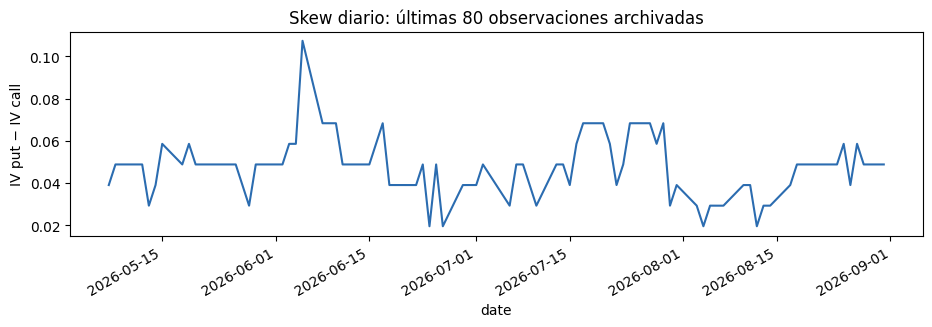

,date,skew,skew_change,expiration,expiry_change,jump_with_expiry_change
0,2020-03-17,0.32194,0.10731,2020-04-17,True,True
1,2020-03-20,0.19512,-0.08780,2020-04-20,True,True
2,2020-03-26,0.24390,0.06830,2020-04-24,False,False
3,2021-01-27,0.13658,0.06829,2021-02-26,False,False
4,2021-11-26,0.13658,0.05854,2021-12-27,True,True
5,2022-10-27,0.08780,0.06829,2022-11-25,False,False
6,2022-10-28,0.02926,-0.05854,2022-11-28,True,True
7,2024-04-25,-0.01951,-0.06829,2024-05-24,False,False
8,2024-08-05,0.12682,0.05853,2024-09-06,True,True
9,2025-04-03,0.07805,0.05854,2025-05-02,False,False


In [8]:
window = selected.tail(80).set_index('date')
ax = window['skew'].plot(figsize=(11, 3), color='#2b6cb0', title='Skew diario: últimas 80 observaciones archivadas')
ax.set_ylabel('IV put − IV call')
plt.show()

jump_view = jumps[['date', 'skew', 'skew_change', 'expiration', 'expiry_change',
                   'jump_with_expiry_change']].copy()
display(jump_view.head(12))

**Interpretación.** Los saltos extremos se marcan antes con `|Δskew| > 0.05`; la columna de vencimiento ayuda a distinguir una discontinuidad de selección de un cambio dentro de la misma serie.

**Límite.** La coincidencia con un cambio de vencimiento no prueba causalidad, y ningún salto se interpreta aquí como predicción de una caída futura.

## 5. Inspección reproducible de una respuesta cruda

Para un día marcado como salto extremo, reutilizamos `read_payload`, `choose_pair` y `quote` de los scripts de auditoría. No recreamos la lógica de selección ni hacemos descargas.

In [9]:
case_date = pd.Timestamp(jumps.iloc[0]['date']).strftime('%Y-%m-%d')
payload = a4.read_payload(a4.existing(case_date))
pair = a3.choose_pair(payload['data'])
raw_case = pd.DataFrame([
    {'lado': 'put', 'id': pair['put']['contractID'], 'fecha_cadena': pair['put']['date'],
     'vencimiento': pair['expiration'], 'delta': pair['put']['delta'],
     'IV_texto_original': pair['put']['implied_volatility'], **a3.quote(pair['put'])},
    {'lado': 'call', 'id': pair['call']['contractID'], 'fecha_cadena': pair['call']['date'],
     'vencimiento': pair['expiration'], 'delta': pair['call']['delta'],
     'IV_texto_original': pair['call']['implied_volatility'], **a3.quote(pair['call'])},
])
print('Caso inspeccionado:', case_date)
display(raw_case)

Caso inspeccionado: 2020-03-17


,lado,id,fecha_cadena,vencimiento,delta,IV_texto_original,bid,ask,spread,flags,usable
0,put,SPY200417P00221000,2020-03-17,2020-04-17,-0.24811,0.82461,10.19,10.35,0.16,none,True
1,call,SPY200417C00282000,2020-03-17,2020-04-17,0.25096,0.50267,5.08,5.24,0.16,none,True


**Interpretación.** Este ejemplo enlaza directamente una fila del reporte con los campos originales del proveedor y la misma función de selección usada en A4.

**Límite.** Es un ejemplo de trazabilidad, no una auditoría manual de todas las cadenas ni una explicación económica del nivel de IV.

## 6. IV idénticas en la muestra fija

La muestra toma la primera sesión de enero y julio de cada año. Se comparan los textos de IV archivados, no valores recalculados.

In [10]:
repeated_put = iv_sample.groupby('put_iv_raw')['date'].agg(list).loc[lambda s: s.str.len() > 1]
repeated_call = iv_sample.groupby('call_iv_raw')['date'].agg(list).loc[lambda s: s.str.len() > 1]
display(pd.concat({'put': repeated_put, 'call': repeated_call}).rename('fechas').to_frame())

fechas
put  0.13195         [2020-01-02 00:00:00, 2023-07-03 00:00:00]
     0.16122         [2022-01-03 00:00:00, 2026-07-01 00:00:00]
     0.17097         [2025-01-02 00:00:00, 2025-07-01 00:00:00]
call 0.09292         [2021-07-01 00:00:00, 2024-07-01 00:00:00]
     0.10268  [2022-01-03 00:00:00, 2023-07-03 00:00:00, 202...
     0.12219         [2025-07-01 00:00:00, 2026-07-01 00:00:00]
     0.20024         [2020-07-01 00:00:00, 2023-01-03 00:00:00]

**Interpretación.** Las IV idénticas pueden reflejar redondeo, discretización o repetición legítima; quedan visibles para que no se sobreinterpreten variaciones muy pequeñas.

**Límite.** Esta muestra no identifica el mecanismo del proveedor. Antes de usar cambios pequeños de skew, conviene documentar precisión, redondeo y metodología de IV.

## Decisiones pendientes para el experimento de alerta

1. Congelar la definición del **evento futuro de riesgo** y el horizonte de anticipación antes de mirar resultados.
2. Definir particiones temporales de desarrollo y evaluación final, sin mezclar información futura.
3. Especificar el benchmark basado solo en precios pasados de SPY y las métricas: anticipación, sensibilidad, falsas alarmas, calibración y cobertura.
4. Decidir cómo tratar los 14 contratos con spread amplio y documentar que no se cambiará la regla después de evaluar desempeño.
5. Verificar o declarar formalmente el horario de publicación EOD; por ahora, una señal de fecha *t* solo está disponible para la sesión siguiente.
6. Resolver si la precisión/repetición de IV del proveedor es suficiente para el efecto mínimo de skew que se pretende estudiar.
7. Solo si lo anterior queda registrado, comparar una señal simple de skew con el benchmark; un HMM sigue siendo opcional y no debe entrenarse todavía.